In [13]:
import os
import sys
from pathlib import Path

import hydra
import rootutils

# Setup root directory
rootutils.setup_root(__file__ if "__file__" in dir() else os.getcwd(), indicator=".project-root", pythonpath=True)

import torch
import torchvision
from torchvision.transforms import v2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torchmetrics.classification import MulticlassConfusionMatrix
from omegaconf import OmegaConf

# Import data components
from src.data.components.transform_subset import TransformSubset

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Model Evaluation Script

This notebook provides comprehensive evaluation tools for models trained with `train.py`:
- Confusion matrices with visualizations
- Per-class metrics (precision, recall, F1-score)
- Per-class loss analysis
- Misclassification analysis
- Comparative analysis across runs

## Configuration

Set the path to your experiment results and configure evaluation parameters.

In [14]:
# Configuration
MODEL_PATH = "../logs/train/SurfaceDefectDetection/Loss_CE/2026-01-21_09-19-39_mobilenet_strong_aug"  # Change to your experiment path
EVAL_PATH = "../logs/eval/SurfaceDefectDetection/ce_strong_aug"
CONFIG_PATH = "../configs"  # Path to your configs directory
CONFIG_NAME = "train.yaml"  # Config file used for training

# Device configuration
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## Load Configuration and Data

Load the training configuration and setup data transformations.

In [15]:
test_data_path = os.path.join("../", "data/surface/test")

test_dataset = torchvision.datasets.ImageFolder(root=test_data_path)

class_names = test_dataset.classes
num_classes = len(class_names)

print(f"\nNumber of classes: {num_classes}")
print(f"Class names: {class_names}")

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Test transforms (same as training)
test_transforms = v2.Compose(
    [
        v2.Resize(480, antialias=True),
        v2.CenterCrop(480),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=mean, std=std),
    ])


Number of classes: 10
Class names: ['bend', 'black_stain', 'corrosion', 'crack', 'deformation', 'missing_part', 'no_deficiencies', 'other', 'silicate_stain', 'water_stain']


In [16]:
# Load configuration
with hydra.initialize(version_base="1.3", config_path=CONFIG_PATH):
    cfg = hydra.compose(config_name=CONFIG_NAME)

# Load hyperparameters if available
hyperparams_path = Path(MODEL_PATH) / "summary" / "hyperparameters.yaml"
if hyperparams_path.exists():
    hyperparams = OmegaConf.load(hyperparams_path)
    print("Loaded hyperparameters from experiment")
else:
    hyperparams = cfg
    print("Using default config (hyperparameters.yaml not found)")

print(hyperparams)

Loaded hyperparameters from experiment
{'research_name': 'SurfaceDefectDetection', 'run_name_postfix': 'mobilenet_strong_aug', 'run_name': '2026-01-21_09-19-39_mobilenet_strong_aug', 'log_path': './logs', 'seed': 42, 'n_runs': 5, 'paths': {'root_dir': '.', 'log_dir': './logs/', 'output_dir': '/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/Loss_CE/2026-01-21_09-19-39_mobilenet_strong_aug', 'work_dir': '/home/lukasb/Documents/NoisyLabelDefectDetection'}, 'trainer': {'_target_': 'lightning.pytorch.trainer.Trainer', 'default_root_dir': '/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/Loss_CE/2026-01-21_09-19-39_mobilenet_strong_aug', 'min_epochs': 10, 'max_epochs': 300, 'accelerator': 'gpu', 'devices': [0], 'check_val_every_n_epoch': 1, 'deterministic': False, 'precision': '16-mixed'}, 'callbacks': {'model_checkpoint': {'_target_': 'lightning.pytorch.callbacks.ModelCheckpoint', 'dirpath': None, 'filename': 'epoch_{epoch

## Load Best Model

Load the best model checkpoint from a specific run.

In [17]:
def load_model():
    """Load the best model from a specific run."""
    model = hydra.utils.instantiate(hyperparams.model, num_classes=num_classes)
    checkpoint_path = Path(MODEL_PATH) / "run_0" / f"checkpoints" / "epoch_230-val_acc_0.8994.ckpt"
    
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Model not found at {checkpoint_path}")
    
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    state = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
    
    model.load_state_dict(state, strict=True)
    model.to(device)
    model.eval()
    
    print(f"Loaded model from: {checkpoint_path}")
    return model

model = load_model()

Loaded model from: ../logs/train/SurfaceDefectDetection/Loss_CE/2026-01-21_09-19-39_mobilenet_strong_aug/run_0/checkpoints/epoch_230-val_acc_0.8994.ckpt


## Generate Predictions on Test Set

Run inference on the test set and collect predictions, targets, and logits.

In [18]:
def get_predictions(model, dataloader, device):
    """Generate predictions and collect all outputs."""
    all_preds = []
    all_targets = []
    all_logits = []
    all_probs = []
    
    model.eval()
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_logits.append(outputs.cpu())
            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
    
    return {
        'predictions': torch.cat(all_preds).numpy(),
        'targets': torch.cat(all_targets).numpy(),
        'logits': torch.cat(all_logits).numpy(),
        'probabilities': torch.cat(all_probs).numpy()
    }

# Create test dataloader
test_dataset_transformed = TransformSubset(
    test_dataset,
    indices=list(range(len(test_dataset))),
    transform=test_transforms
)

test_loader = torch.utils.data.DataLoader(
    test_dataset_transformed,
    batch_size=hyperparams.data.get("batch_size", 32),
    shuffle=False,
    num_workers=4
)

# Get predictions
print("Generating predictions on test set...")
results = get_predictions(model, test_loader, device)
print(f"Generated predictions for {len(results['predictions'])} samples")

Generating predictions on test set...
Generated predictions for 377 samples


## Confusion Matrix Visualization

Generate and visualize confusion matrices to understand classification patterns.

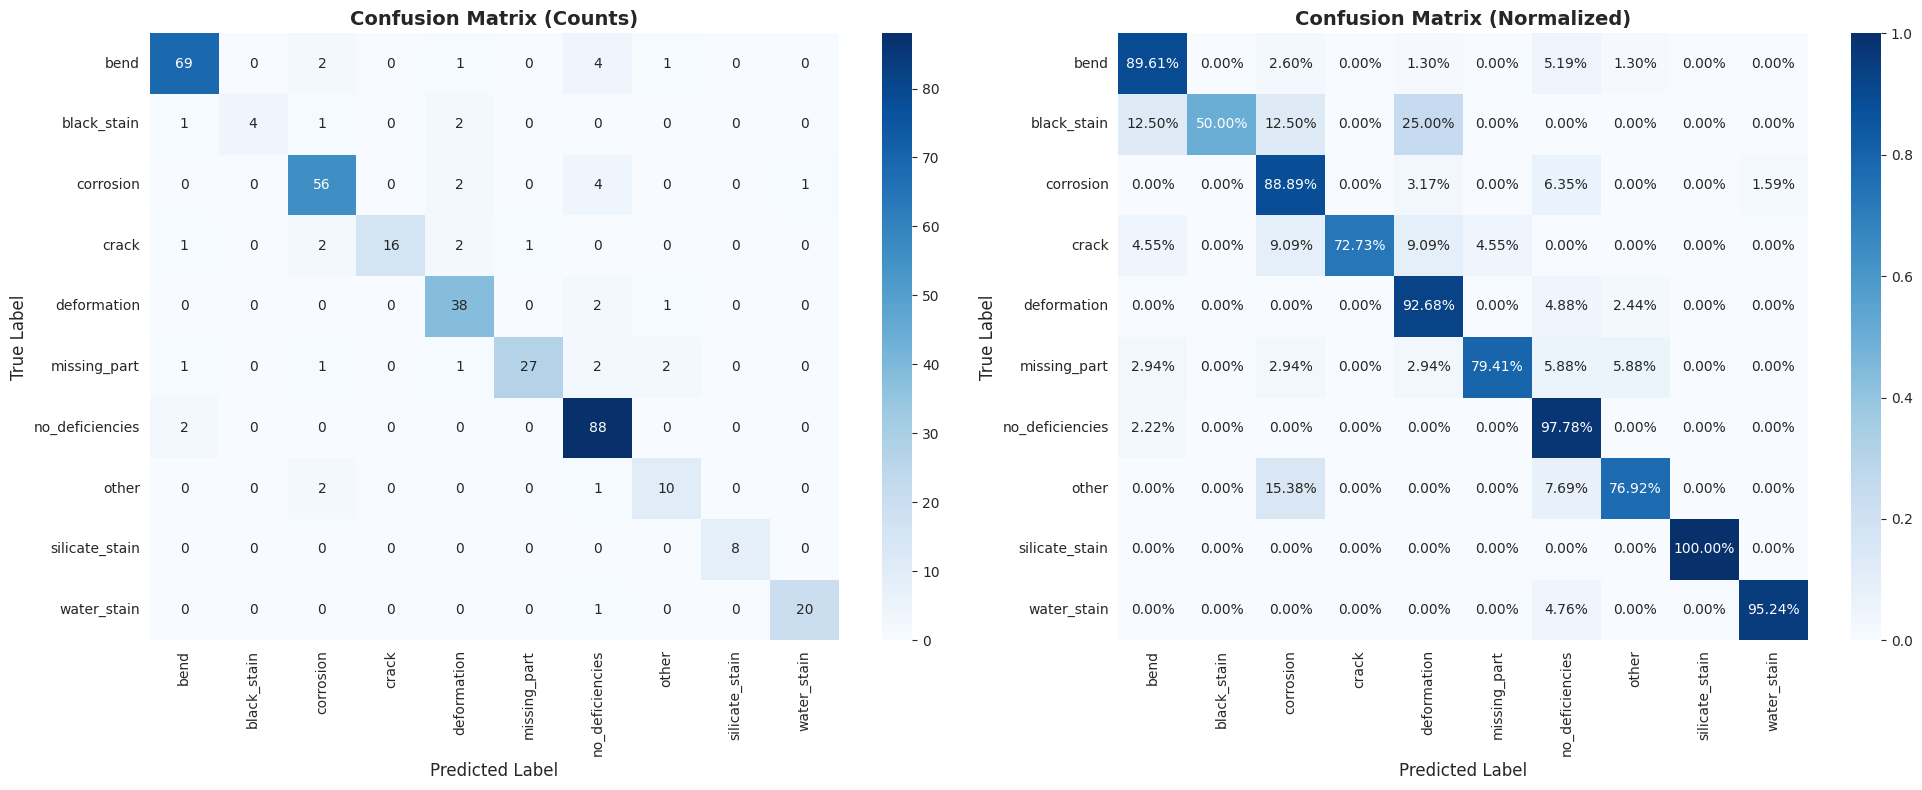

Saved confusion matrix to ../logs/eval/SurfaceDefectDetection/ce_strong_aug/confusion_matrix.png


In [19]:
# Compute confusion matrix
cm = confusion_matrix(results['targets'], results['predictions'])

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix (counts)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Confusion matrix with counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label', fontsize=12)

# Confusion matrix with percentages
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=12)
ax2.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

# Save confusion matrix
save_path = Path(EVAL_PATH) / "confusion_matrix.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved confusion matrix to {save_path}")

## Per-Class Metrics

Compute and visualize per-class precision, recall, and F1-score.

Classification Report:
                 precision    recall  f1-score     support
bend              0.932432  0.896104  0.913907   77.000000
black_stain       1.000000  0.500000  0.666667    8.000000
corrosion         0.875000  0.888889  0.881890   63.000000
crack             1.000000  0.727273  0.842105   22.000000
deformation       0.826087  0.926829  0.873563   41.000000
missing_part      0.964286  0.794118  0.870968   34.000000
no_deficiencies   0.862745  0.977778  0.916667   90.000000
other             0.714286  0.769231  0.740741   13.000000
silicate_stain    1.000000  1.000000  1.000000    8.000000
water_stain       0.952381  0.952381  0.952381   21.000000
accuracy          0.891247  0.891247  0.891247    0.891247
macro avg         0.912722  0.843260  0.865889  377.000000
weighted avg      0.897905  0.891247  0.889518  377.000000


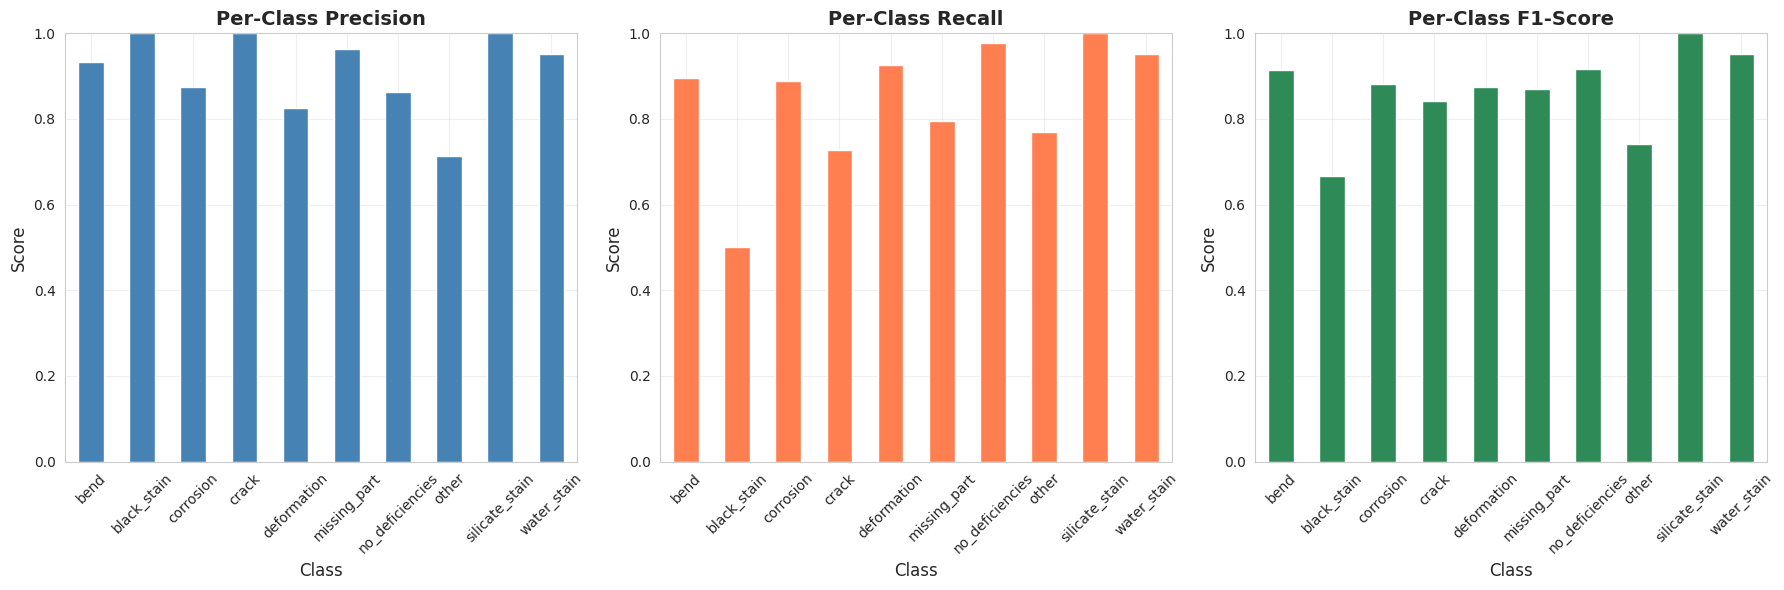

Saved per-class metrics to ../logs/eval/SurfaceDefectDetection/ce_strong_aug/per_class_metrics.png
Saved classification report to ../logs/eval/SurfaceDefectDetection/ce_strong_aug/classification_report.csv


In [20]:
# Generate classification report
report = classification_report(
    results['targets'], 
    results['predictions'], 
    target_names=class_names,
    output_dict=True
)

# Convert to DataFrame for better visualization
report_df = pd.DataFrame(report).transpose()

# Display the report
print("Classification Report:")
print(report_df.to_string())

# Plot per-class metrics
metrics_df = report_df.iloc[:-3]  # Exclude accuracy, macro avg, weighted avg

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Precision
metrics_df['precision'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Per-Class Precision', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Recall
metrics_df['recall'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Per-Class Recall', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylim([0, 1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# F1-Score
metrics_df['f1-score'].plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Per-Class F1-Score', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Score', fontsize=12)
axes[2].set_xlabel('Class', fontsize=12)
axes[2].set_ylim([0, 1])
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save metrics
save_path = Path(EVAL_PATH) / "per_class_metrics.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved per-class metrics to {save_path}")

# Save classification report
report_path = Path(EVAL_PATH) / "classification_report.csv"
report_df.to_csv(report_path)
print(f"Saved classification report to {report_path}")

## Misclassification Analysis

Identify and analyze the most common misclassifications.

Total misclassified samples: 41 / 377 (10.88%)

Top 10 Most Common Misclassifications:
     true_class predicted_class  count
           bend no_deficiencies      4
      corrosion no_deficiencies      4
           bend       corrosion      2
    black_stain     deformation      2
      corrosion     deformation      2
   missing_part           other      2
    deformation no_deficiencies      2
          crack       corrosion      2
          crack     deformation      2
no_deficiencies            bend      2


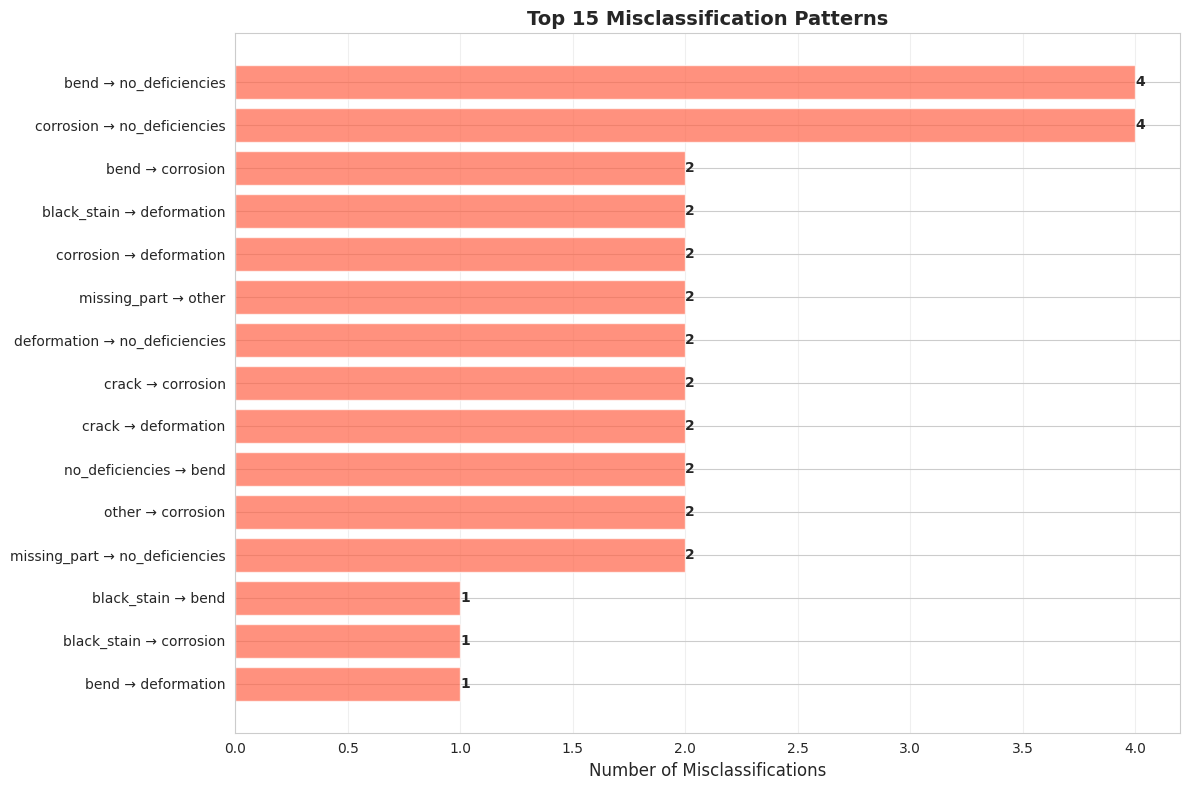


Saved misclassification patterns to ../logs/eval/SurfaceDefectDetection/ce_strong_aug/misclassification_patterns.png
Saved detailed misclassification data to ../logs/eval/SurfaceDefectDetection/ce_strong_aug/misclassifications.csv


In [21]:
# Find misclassified samples
misclassified_mask = results['predictions'] != results['targets']
misclassified_indices = np.where(misclassified_mask)[0]

print(f"Total misclassified samples: {len(misclassified_indices)} / {len(results['targets'])} ({100*len(misclassified_indices)/len(results['targets']):.2f}%)")

# Analyze misclassification patterns
misclassification_pairs = []
for idx in misclassified_indices:
    true_class = results['targets'][idx]
    pred_class = results['predictions'][idx]
    confidence = results['probabilities'][idx][pred_class]
    
    misclassification_pairs.append({
        'sample_idx': idx,
        'true_class': class_names[true_class],
        'predicted_class': class_names[pred_class],
        'confidence': confidence,
        'true_class_prob': results['probabilities'][idx][true_class]
    })

misclass_df = pd.DataFrame(misclassification_pairs)

# Count most common misclassification pairs
misclass_counts = misclass_df.groupby(['true_class', 'predicted_class']).size().reset_index(name='count')
misclass_counts = misclass_counts.sort_values('count', ascending=False)

print("\nTop 10 Most Common Misclassifications:")
print(misclass_counts.head(10).to_string(index=False))

# Visualize misclassification patterns
top_n = min(15, len(misclass_counts))
top_misclass = misclass_counts.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(top_misclass))
bars = ax.barh(y_pos, top_misclass['count'], color='tomato', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row['true_class']} → {row['predicted_class']}" 
                     for _, row in top_misclass.iterrows()])
ax.invert_yaxis()
ax.set_xlabel('Number of Misclassifications', fontsize=12)
ax.set_title(f'Top {top_n} Misclassification Patterns', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{int(width)}',
            ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Save misclassification analysis
save_path = Path(EVAL_PATH) / "misclassification_patterns.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nSaved misclassification patterns to {save_path}")

misclass_csv_path = Path(EVAL_PATH) / "misclassifications.csv"
misclass_df.to_csv(misclass_csv_path, index=False)
print(f"Saved detailed misclassification data to {misclass_csv_path}")

## Confidence Distribution Analysis

Analyze prediction confidence for correct vs incorrect predictions.

/tmp/ipykernel_2683546/1394116183.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=['Correct', 'Incorrect'], patch_artist=True)


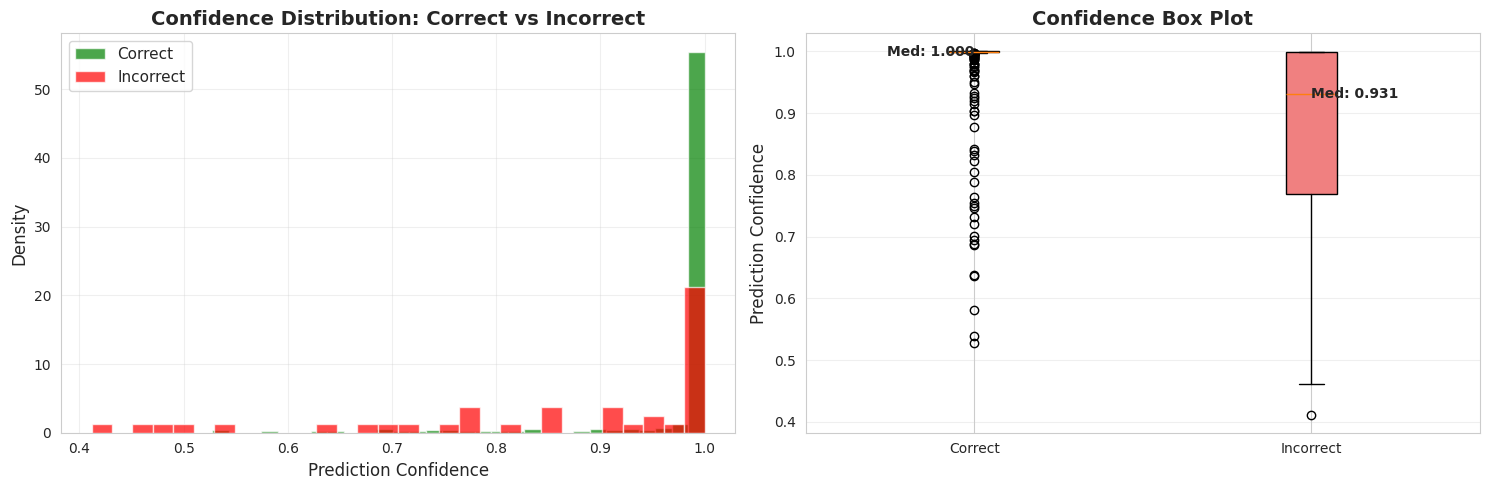

Saved confidence distribution to ../logs/eval/SurfaceDefectDetection/ce_strong_aug/confidence_distribution.png

Confidence Statistics:
Correct predictions - Mean: 0.978, Median: 1.000, Std: 0.073
Incorrect predictions - Mean: 0.856, Median: 0.931, Std: 0.175


In [22]:
# Get max confidence for each prediction
max_confidences = np.max(results['probabilities'], axis=1)
correct_mask = results['predictions'] == results['targets']

correct_confidences = max_confidences[correct_mask]
incorrect_confidences = max_confidences[~correct_mask]

# Plot confidence distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(correct_confidences, bins=30, alpha=0.7, label='Correct', color='green', density=True)
axes[0].hist(incorrect_confidences, bins=30, alpha=0.7, label='Incorrect', color='red', density=True)
axes[0].set_xlabel('Prediction Confidence', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Confidence Distribution: Correct vs Incorrect', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Box plot
box_data = [correct_confidences, incorrect_confidences]
bp = axes[1].boxplot(box_data, labels=['Correct', 'Incorrect'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Prediction Confidence', fontsize=12)
axes[1].set_title('Confidence Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add statistics
axes[1].text(1, np.median(correct_confidences), f'Med: {np.median(correct_confidences):.3f}', 
             ha='right', va='center', fontsize=10, fontweight='bold')
axes[1].text(2, np.median(incorrect_confidences), f'Med: {np.median(incorrect_confidences):.3f}', 
             ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Save confidence distribution
save_path = Path(EVAL_PATH) / "confidence_distribution.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved confidence distribution to {save_path}")

# Print statistics
print(f"\nConfidence Statistics:")
print(f"Correct predictions - Mean: {correct_confidences.mean():.3f}, Median: {np.median(correct_confidences):.3f}, Std: {correct_confidences.std():.3f}")
print(f"Incorrect predictions - Mean: {incorrect_confidences.mean():.3f}, Median: {np.median(incorrect_confidences):.3f}, Std: {incorrect_confidences.std():.3f}")

## Per-Class Confidence Analysis

Analyze prediction confidence for each class separately.

Per-Class Confidence Statistics:
                     mean    median       std       min       max  count
silicate_stain   0.999991  0.999998  0.000016  0.999950  1.000000    8.0
no_deficiencies  0.987541  0.999969  0.057305  0.539529  1.000000   90.0
water_stain      0.984054  0.999922  0.056820  0.732449  1.000000   21.0
deformation      0.978601  0.999943  0.052940  0.746870  1.000000   41.0
missing_part     0.968326  0.999807  0.090805  0.543444  1.000000   34.0
corrosion        0.955487  0.999991  0.111864  0.411670  1.000000   63.0
other            0.946673  0.999400  0.096391  0.688590  1.000000   13.0
bend             0.945450  0.999756  0.121687  0.461452  1.000000   77.0
crack            0.930777  0.998770  0.135889  0.479392  1.000000   22.0
black_stain      0.922350  0.997522  0.161557  0.503939  0.999999    8.0


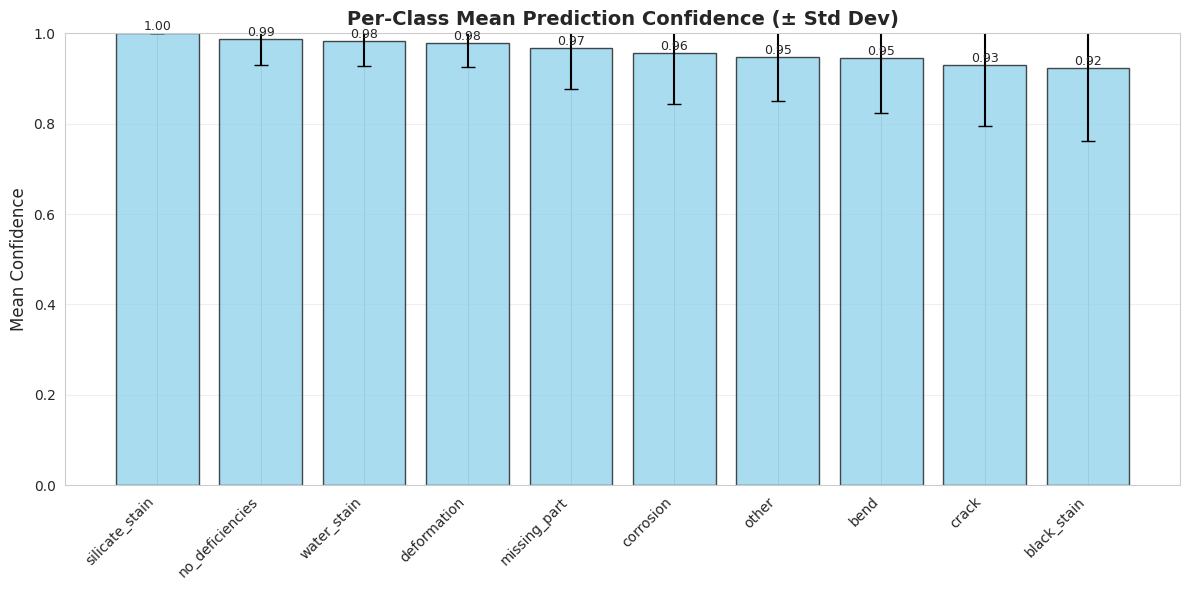


Saved per-class confidence to ../logs/eval/SurfaceDefectDetection/ce_strong_aug/per_class_confidence.png
Saved per-class confidence data to ../logs/eval/SurfaceDefectDetection/ce_strong_aug/per_class_confidence.csv


In [23]:
# Compute per-class confidence statistics
per_class_confidence = {}

for class_idx, class_name in enumerate(class_names):
    class_mask = results['targets'] == class_idx
    class_confidences = max_confidences[class_mask]
    
    if len(class_confidences) > 0:
        per_class_confidence[class_name] = {
            'mean': class_confidences.mean(),
            'median': np.median(class_confidences),
            'std': class_confidences.std(),
            'min': class_confidences.min(),
            'max': class_confidences.max(),
            'count': len(class_confidences)
        }

# Create DataFrame
confidence_stats_df = pd.DataFrame(per_class_confidence).T
confidence_stats_df = confidence_stats_df.sort_values('mean', ascending=False)

print("Per-Class Confidence Statistics:")
print(confidence_stats_df.to_string())

# Plot per-class mean confidence
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(confidence_stats_df))
bars = ax.bar(x_pos, confidence_stats_df['mean'], 
              yerr=confidence_stats_df['std'], 
              capsize=5, alpha=0.7, color='skyblue', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(confidence_stats_df.index, rotation=45, ha='right')
ax.set_ylabel('Mean Confidence', fontsize=12)
ax.set_title('Per-Class Mean Prediction Confidence (± Std Dev)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, (idx, row)) in enumerate(zip(bars, confidence_stats_df.iterrows())):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Save per-class confidence
save_path = Path(EVAL_PATH) / "per_class_confidence.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nSaved per-class confidence to {save_path}")

confidence_csv_path = Path(EVAL_PATH) / "per_class_confidence.csv"
confidence_stats_df.to_csv(confidence_csv_path)
print(f"Saved per-class confidence data to {confidence_csv_path}")

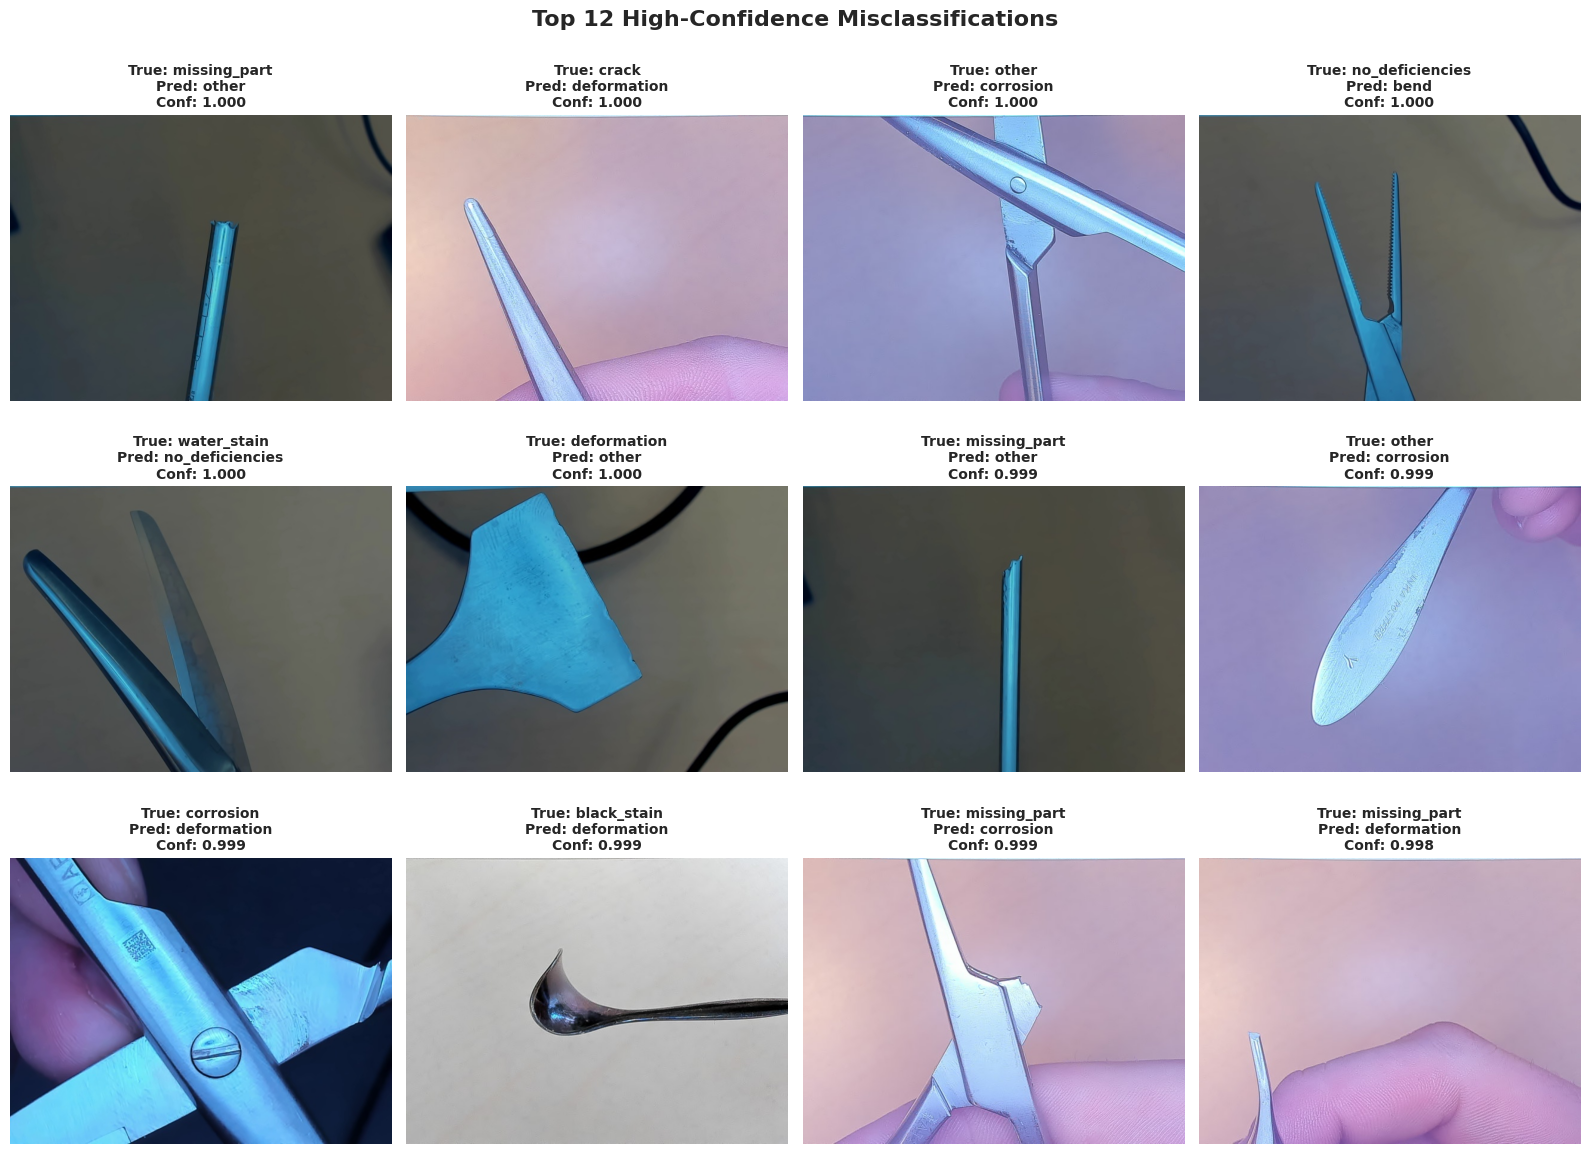


Saved high-confidence errors visualization to ../logs/eval/SurfaceDefectDetection/ce_strong_aug/high_confidence_errors.png

Top 12 High-Confidence Errors:
 sample_idx      true_class predicted_class  confidence  true_class_prob
        225    missing_part           other    0.999974         0.000012
        166           crack     deformation    0.999939         0.000031
        344           other       corrosion    0.999910         0.000076
        268 no_deficiencies            bend    0.999713         0.000147
        358     water_stain no_deficiencies    0.999644         0.000069
        193     deformation           other    0.999575         0.000295
        228    missing_part           other    0.999429         0.000001
        346           other       corrosion    0.999400         0.000005
        100       corrosion     deformation    0.998995         0.000060
         81     black_stain     deformation    0.998707         0.000001
        244    missing_part       corrosi

In [24]:
# Get high confidence incorrect predictions
high_conf_errors = misclass_df.nlargest(12, 'confidence')

# Create figure for displaying images
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

# Load and display images
for idx, (_, row) in enumerate(high_conf_errors.iterrows()):
    sample_idx = row['sample_idx']
    
    # Get the image path
    img_path = test_dataset.imgs[sample_idx][0]
    img = plt.imread(img_path)
    
    # Display image
    axes[idx].imshow(img)
    axes[idx].axis('off')
    
    # Create title with error information
    title = f"True: {row['true_class']}\n"
    title += f"Pred: {row['predicted_class']}\n"
    title += f"Conf: {row['confidence']:.3f}"
    axes[idx].set_title(title, fontsize=10, fontweight='bold')

plt.suptitle('Top 12 High-Confidence Misclassifications', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Save the figure
save_path = Path(EVAL_PATH) / "high_confidence_errors.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nSaved high-confidence errors visualization to {save_path}")

# Print detailed information
print("\nTop 12 High-Confidence Errors:")
print(high_conf_errors[['sample_idx', 'true_class', 'predicted_class', 'confidence', 'true_class_prob']].to_string(index=False))